In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from src.resource_estimates.gate_costs.free_fermionic import Occupation
from src.resource_estimates.gate_costs.FFFT import FFFT
from src.resource_estimates.gate_costs.interactions import ShiftedOccupationPair
from src.resource_estimates.gate_costs.hubbard_commutators import SpinSymmetricMixedControlledHappa, SpinSymmetricMixedControlledKappa
from src.resource_estimates.gate_costs.hamming_weight_phasing import HWPGate

from src.hubbard_models.split_operator_error_coefficients import (
    plaquette_second_order_split_operator_error_coefficient,
    fourth_order_suzuki_trotter_split_operator_error_coefficient,
    fourth_order_augmented_split_operator_error_coefficients,
)

from src.resource_estimates.hamiltonian_simulation import hamiltonian_simulation_cost
from src.resource_estimates.quantum_phase_estimation import adaptive_phase_estimation_resources

In [2]:
tau = 0.5
U = 4
D = 2
x = 0.01

def trotter_gates_2nd_order(logn: int, D: int) -> tuple[dict,...]:
    n = 2**logn
    N = n**D
    return {
        HWPGate({ShiftedOccupationPair(): N}, N): 1,
        HWPGate({FFFT(logn, D, 1):1}, n): 2,
        Occupation(): 2*N,
    },{
        HWPGate({ShiftedOccupationPair(): N}, N): 1
    }

def trotter_gates_4th_order(logn: int, D: int) -> tuple[dict,...]:
    n = 2**logn
    N = n**D
    return {
        HWPGate({ShiftedOccupationPair(): N}, N): 5,
        HWPGate({FFFT(logn, D, 1):1}, n): 5,
        Occupation(): 5*2*N
    },{
        HWPGate({ShiftedOccupationPair(): N}, N): 1
    }

def augmented_gates(logn: int, D: int) -> tuple[dict,...]:
    n = 2**logn
    N = n**D
    return {
        HWPGate({ShiftedOccupationPair(): N}, N): 2,
        HWPGate({FFFT(logn, D, 1):1}, n): 2,
        Occupation(): 2*N,
        HWPGate({SpinSymmetricMixedControlledHappa(): N // 2}, N //2): 2*D
    },{
        HWPGate({FFFT(logn, D, 1):1}, n): 2,
        Occupation(): 2*N,
        HWPGate({SpinSymmetricMixedControlledKappa(): N // 2}, N //2): 2*D
    }

def augmented_gates_trotter(logn: int, D: int) -> tuple[dict,...]:
    n = 2**logn
    N = n**D
    return {
        HWPGate({ShiftedOccupationPair(): N}, N): 2,
        HWPGate({FFFT(logn, D, 1):1}, n): 2,
        Occupation(): 2*N,
        HWPGate({SpinSymmetricMixedControlledHappa(): N // 2}, N //2): 2*D
    },{
        HWPGate({FFFT(logn, D, 1):1}, n): 2,
        Occupation(): 2*N,
        HWPGate({SpinSymmetricMixedControlledKappa(): N // 2}, N //2): 2*D*2
    }

gate_gens_1 = [trotter_gates_2nd_order, trotter_gates_4th_order, augmented_gates_trotter]
gate_gens_2 = [trotter_gates_2nd_order, trotter_gates_4th_order, augmented_gates]

def dict_to_t_count(dct: dict) -> int:
    tc = 0
    if "t" in dct.keys():
        tc += dct["t"] 
        
    if "tdg" in dct.keys():
        tc += dct["tdg"] 
        
    if "toffoli" in dct.keys():
        tc += 4*dct["toffoli"]
    return tc

In [3]:
def get_error_coefficients(n: int, D: int, U: float, tau: float, label: str, unitary_decomp: bool = True) -> dict:
    N = n**D
    match label:
        case "SO-FFFT 2":
            hopping_graph = nx.grid_graph([n]*D, periodic=True)
            return {3: plaquette_second_order_split_operator_error_coefficient(U, tau, N, hopping_graph)}
        case "SO-FFFT 4":
            return {5: fourth_order_suzuki_trotter_split_operator_error_coefficient(U, tau, N, 2*D)}
        case "SO-FFFT Augmented":
            return {5 + i: x for i,x in enumerate(fourth_order_augmented_split_operator_error_coefficients(U, tau, N, 2*D, unitary_decomp))}

for strat in ["SO-FFFT 2", "SO-FFFT 4", "SO-FFFT Augmented"]:
    print(get_error_coefficients(4, 2, U, tau, strat, False))

{3: np.float64(86.59236254666554)}
{5: 109222.29759999999}
{5: 108470.04444444444, 6: 227.55555555555554, 7: 693101.7142857143}


# Hubbard model on the square lattice with powers of 2 side-lengths

## Hamiltonian simulation:

/home/aftkvantify/lie-algebra-trotterization/src/resource_estimates/rotation_synthesis.py:43: UserWarning: When synthesizing rotation into clifford plus T, this function does not compute the single-qubit clifford count due to arbitrary rotations.
  warnings.warn(


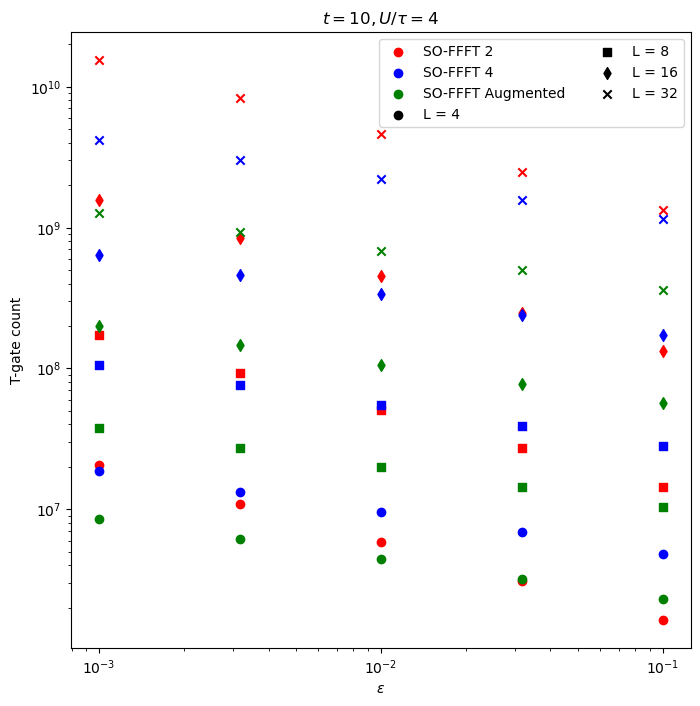

In [4]:
t = 10
logeps_list = np.linspace(-3, -1, 5)
eps_list = np.pow(10, logeps_list)
Ls = [4, 8, 16, 32]

colors = ['r', 'b', 'g']
marker_styles = ['o', 's', 'd', 'x']
comp_strats = ["SO-FFFT 2", "SO-FFFT 4", "SO-FFFT Augmented"]

fig, ax = plt.subplots(figsize = (8, 8))

for strat, color in zip(comp_strats, colors):
    ax.scatter([],[], c = color, marker = "o", label = strat)
    
for L, marker in zip(Ls, marker_styles):
    ax.scatter([],[], c = "k", marker = marker, label = f"L = {L}")

ax.set_xscale("log")
ax.set_yscale("log")
ax.legend(ncol = 2)
ax.set_xlabel(rf"$\varepsilon$")
ax.set_ylabel(f"T-gate count")
ax.legend(ncol = 2)
ax.set_title(rf"$t = {t}, U / \tau = {U}$")

for gate_gen, color, comp_strat in zip(gate_gens_1, colors, comp_strats):
    for L, marker_style in zip(Ls, marker_styles):
        t_gates, u_gates = gate_gen(int(np.log2(L)), D)
        dcts = [hamiltonian_simulation_cost(
            t, 
            e, 
            t_gates, 
            outer_gates=u_gates, 
            error_coefficients=get_error_coefficients(L, D, U, tau, comp_strat, True),
            x=x,
            synthesize_rotation_with="RUS"
        )
            for e in eps_list
               ]
        ys = [dict_to_t_count(d) for d in dcts]
        ax.scatter(eps_list, ys, marker = marker_style, c = color)

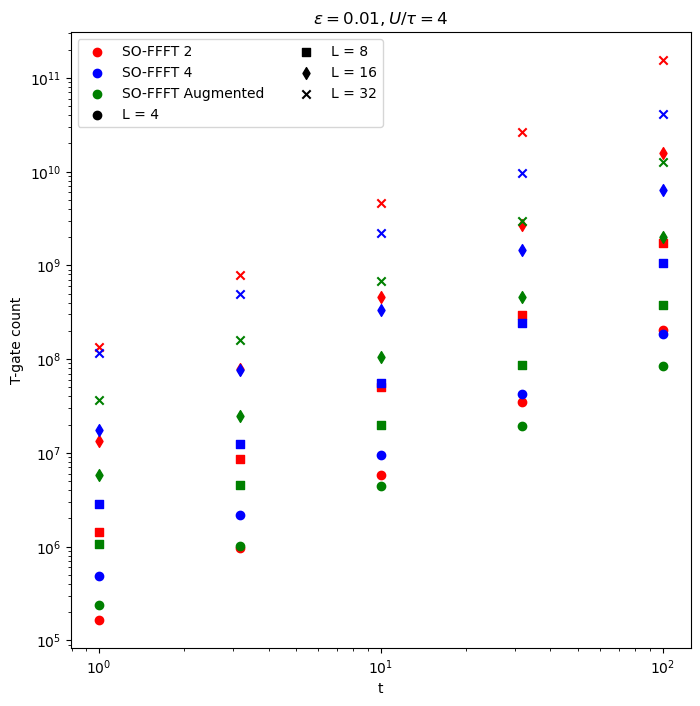

In [5]:
logts = np.linspace(0, 2, 5)
ts = np.pow(10, logts)
eps = 0.01
Ls = [4, 8, 16, 32]

colors = ['r', 'b', 'g']
marker_styles = ['o', 's', 'd', 'x']
comp_strats = ["SO-FFFT 2", "SO-FFFT 4", "SO-FFFT Augmented"]

fig, ax = plt.subplots(figsize = (8, 8))

for strat, color in zip(comp_strats, colors):
    ax.scatter([],[], c = color, marker = "o", label = strat)
    
for L, marker in zip(Ls, marker_styles):
    ax.scatter([],[], c = "k", marker = marker, label = f"L = {L}")

ax.set_xscale("log")
ax.set_yscale("log")
ax.legend(ncol = 2)
ax.set_xlabel(rf"t")
ax.set_ylabel(f"T-gate count")
ax.legend(ncol = 2)
ax.set_title(rf"$\varepsilon = {eps}, U / \tau = {U}$")

for gate_gen, color, comp_strat in zip(gate_gens_1, colors, comp_strats):
    for L, marker_style in zip(Ls, marker_styles):
        t_gates, u_gates = gate_gen(int(np.log2(L)), D)
        dcts = [hamiltonian_simulation_cost(
            t, 
            eps, 
            t_gates, 
            outer_gates=u_gates, 
            error_coefficients=get_error_coefficients(L, D, U, tau, comp_strat, True),
            x=x,
            synthesize_rotation_with="RUS"
        )
            for t in ts
               ]
        ys = [dict_to_t_count(d) for d in dcts]
        ax.scatter(ts, ys, marker = marker_style, c = color)

## Quantum Phase Estimation

SO-FFFT 2
4
[80552599972, 5478230509, 368643824, 24487045, 1601836]
8
[77590481836, 5300342117, 358632106, 23574480, 1557680]
16
[80123086408, 5435138294, 369988307, 24952080, 1693709]


/home/aftkvantify/lie-algebra-trotterization/src/resource_estimates/quantum_phase_estimation.py:144: UserWarning: minimize failed to converge with msg:
ABNORMAL: 
  warnings.warn(


32
[92117835059, 6319403024, 429955462, 29019292, 2002187]
SO-FFFT 4
4
[60311862380, 6281952550, 657856820, 68169380, 6823400]
8
[54884522063, 5804176998, 608620211, 61993240, 6339774]
16
[54189801371, 5742734040, 593905664, 61792982, 6238935]
32
[58189417127, 6070647496, 637286220, 66234124, 6817535]
SO-FFFT Augmented
4
[26253469240, 2798200816, 291732310, 30622980, 3208920]
8
[18639748902, 2002772394, 211247792, 22513704, 2441224]
16
[16429374352, 1761246352, 190367360, 20489242, 2391078]
32
[17345603864, 1880833724, 204480640, 22793900, 3027154]


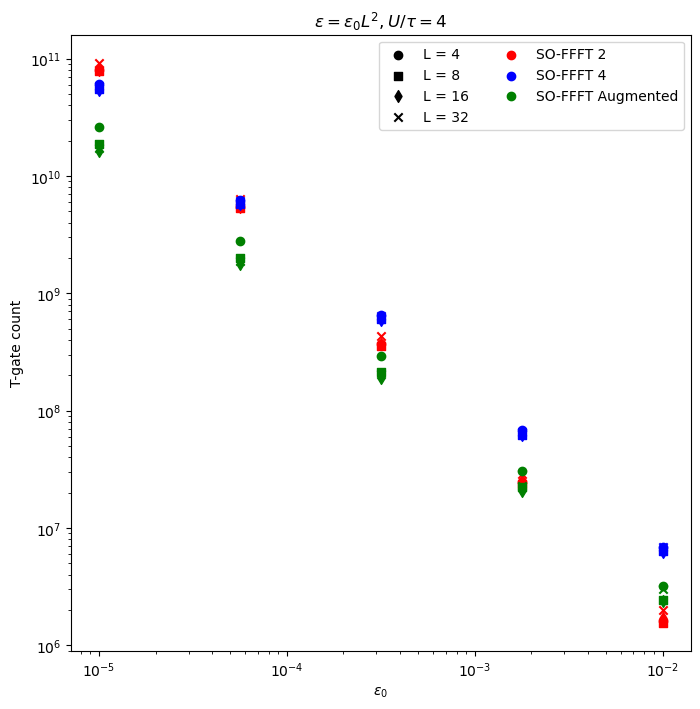

In [6]:
logeps_list = np.linspace(-5, -2, 5)
eps_list = np.pow(10, logeps_list)
Ls = [4, 8, 16, 32]

colors = ['r', 'b', 'g']
marker_styles = ['o', 's', 'd', 'x']
comp_strats = ["SO-FFFT 2", "SO-FFFT 4", "SO-FFFT Augmented"]

fig, ax = plt.subplots(figsize = (8, 8))

for L, marker in zip(Ls, marker_styles):
    ax.scatter([],[], c = "k", marker = marker, label = f"L = {L}")
for strat, color in zip(comp_strats, colors):
    ax.scatter([],[], c = color, marker = "o", label = strat)

ax.set_xscale("log")
ax.set_yscale("log")
ax.legend(ncol = 2)
ax.set_xlabel(rf"$\varepsilon_0$")
ax.set_ylabel(f"T-gate count")
ax.legend(ncol = 2)
ax.set_title(rf"$\varepsilon = \varepsilon_0L^2, U / \tau = {U}$")

for gate_gen, color, comp_strat in zip(gate_gens_2, colors, comp_strats):
    print(comp_strat)
    for L, marker_style in zip(Ls, marker_styles):
        t_gates, u_gates = gate_gen(int(np.log2(L)), D)
        dcts = [adaptive_phase_estimation_resources(
            e * L**2, 
            t_gates, 
            unitary_gates=u_gates, 
            unitary_error_coefficients=get_error_coefficients(L, D, U, tau, comp_strat, False),
            x=x,
            synthesize_rotation_with="RUS"
        )
            for e in eps_list
               ]
        ys = [dict_to_t_count(d) for d in dcts]
        print(L)
        print(ys)
        ax.scatter(eps_list, ys, marker = marker_style, c = color)

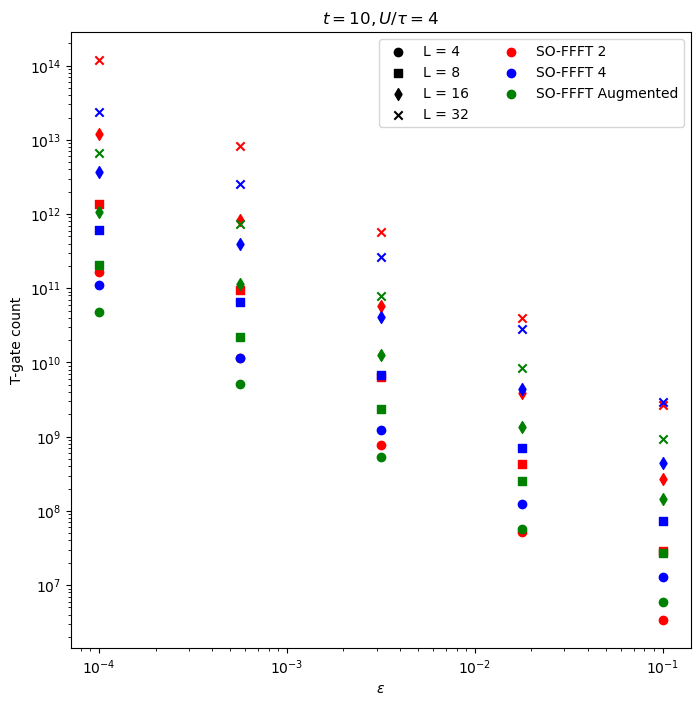

In [7]:
logeps_list = np.linspace(-4, -1, 5)
eps_list = np.pow(10, logeps_list)
Ls = [4, 8, 16, 32]

colors = ['r', 'b', 'g']
marker_styles = ['o', 's', 'd', 'x']
comp_strats = ["SO-FFFT 2", "SO-FFFT 4", "SO-FFFT Augmented"]

fig, ax = plt.subplots(figsize = (8, 8))

for L, marker in zip(Ls, marker_styles):
    ax.scatter([],[], c = "k", marker = marker, label = f"L = {L}")
for strat, color in zip(comp_strats, colors):
    ax.scatter([],[], c = color, marker = "o", label = strat)

ax.set_xscale("log")
ax.set_yscale("log")
ax.legend(ncol = 2)
ax.set_xlabel(rf"$\varepsilon$")
ax.set_ylabel(f"T-gate count")
ax.legend(ncol = 2)
ax.set_title(rf"$t = {t}, U / \tau = {U}$")

for gate_gen, color, comp_strat in zip(gate_gens_2, colors, comp_strats):
    for L, marker_style in zip(Ls, marker_styles):
        t_gates, u_gates = gate_gen(int(np.log2(L)), D)
        dcts = [adaptive_phase_estimation_resources(
            e, 
            t_gates, 
            unitary_gates=u_gates, 
            unitary_error_coefficients=get_error_coefficients(L, D, U, tau, comp_strat, False),
            x=x,
            synthesize_rotation_with="RUS"
        )
            for e in eps_list
               ]
        ys = [dict_to_t_count(d) for d in dcts]
        ax.scatter(eps_list, ys, marker = marker_style, c = color)

# The Hubbard model on the cubic lattice:

In [8]:
tau = 0.5
U = 4
D = 3
x = 0.01

## Hamiltonian simulation:

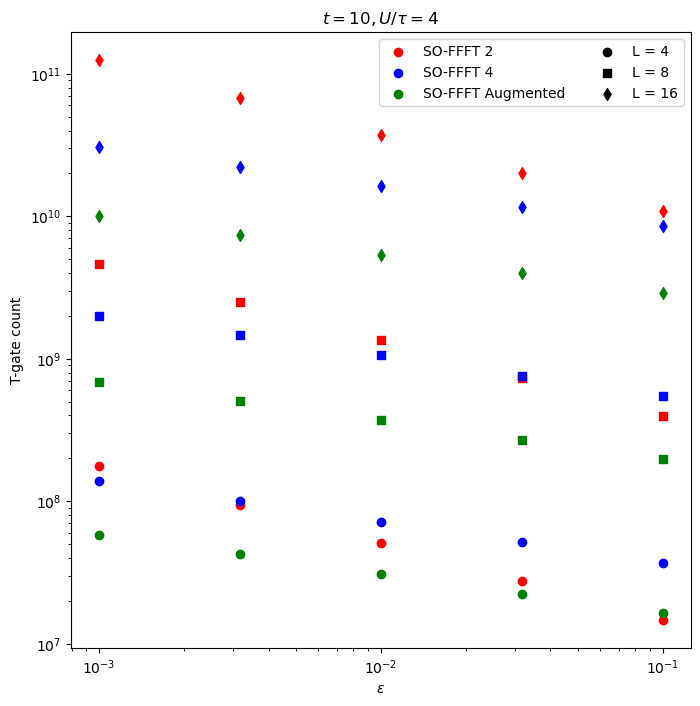

In [9]:
t = 10
logeps_list = np.linspace(-3, -1, 5)
eps_list = np.pow(10, logeps_list)
Ls = [4, 8, 16]

colors = ['r', 'b', 'g']
marker_styles = ['o', 's', 'd']
comp_strats = ["SO-FFFT 2", "SO-FFFT 4", "SO-FFFT Augmented"]

fig, ax = plt.subplots(figsize = (8, 8))

for strat, color in zip(comp_strats, colors):
    ax.scatter([],[], c = color, marker = "o", label = strat)
    
for L, marker in zip(Ls, marker_styles):
    ax.scatter([],[], c = "k", marker = marker, label = f"L = {L}")

ax.set_xscale("log")
ax.set_yscale("log")
ax.legend(ncol = 2)
ax.set_xlabel(rf"$\varepsilon$")
ax.set_ylabel(f"T-gate count")
ax.legend(ncol = 2)
ax.set_title(rf"$t = {t}, U / \tau = {U}$")

for gate_gen, color, comp_strat in zip(gate_gens_1, colors, comp_strats):
    for L, marker_style in zip(Ls, marker_styles):
        t_gates, u_gates = gate_gen(int(np.log2(L)), D)
        dcts = [hamiltonian_simulation_cost(
            t, 
            e, 
            t_gates, 
            outer_gates=u_gates, 
            error_coefficients=get_error_coefficients(L, D, U, tau, comp_strat, True),
            x=x,
            synthesize_rotation_with="RUS"
        )
            for e in eps_list
               ]
        ys = [dict_to_t_count(d) for d in dcts]
        ax.scatter(eps_list, ys, marker = marker_style, c = color)

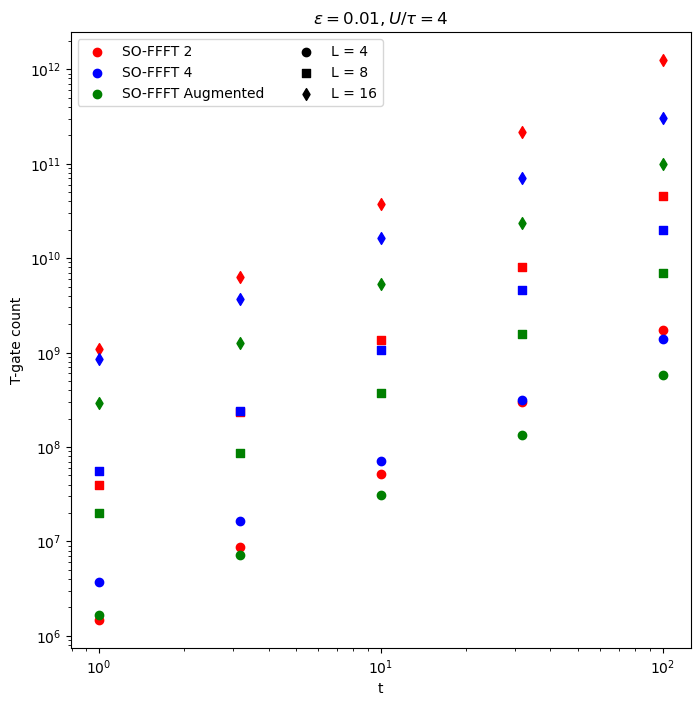

In [10]:
logts = np.linspace(0, 2, 5)
ts = np.pow(10, logts)
eps = 0.01
Ls = [4, 8, 16]

colors = ['r', 'b', 'g']
marker_styles = ['o', 's', 'd']
comp_strats = ["SO-FFFT 2", "SO-FFFT 4", "SO-FFFT Augmented"]

fig, ax = plt.subplots(figsize = (8, 8))

for strat, color in zip(comp_strats, colors):
    ax.scatter([],[], c = color, marker = "o", label = strat)
    
for L, marker in zip(Ls, marker_styles):
    ax.scatter([],[], c = "k", marker = marker, label = f"L = {L}")

ax.set_xscale("log")
ax.set_yscale("log")
ax.legend(ncol = 2)
ax.set_xlabel(rf"t")
ax.set_ylabel(f"T-gate count")
ax.legend(ncol = 2)
ax.set_title(rf"$\varepsilon = {eps}, U / \tau = {U}$")

for gate_gen, color, comp_strat in zip(gate_gens_1, colors, comp_strats):
    for L, marker_style in zip(Ls, marker_styles):
        t_gates, u_gates = gate_gen(int(np.log2(L)), D)
        dcts = [hamiltonian_simulation_cost(
            t, 
            eps, 
            t_gates, 
            outer_gates=u_gates, 
            error_coefficients=get_error_coefficients(L, D, U, tau, comp_strat, True),
            x=x,
            synthesize_rotation_with="RUS"
        )
            for t in ts
               ]
        ys = [dict_to_t_count(d) for d in dcts]
        ax.scatter(ts, ys, marker = marker_style, c = color)

## Quantum Phase Estimation

SO-FFFT 2
4
[79076994704, 5393809470, 364288484, 23881614, 1572856]
8
[80467522208, 5515005038, 374722344, 25229082, 1721656]
16
[87512667162, 6046775830, 415345015, 28122195, 2001488]
SO-FFFT 4
4
[71973090420, 7499297358, 785652630, 81453024, 8169312]
8
[68922294392, 7292657940, 752443038, 78157836, 8216184]
16
[70579763190, 7380929460, 778181268, 81301044, 9892224]
SO-FFFT Augmented
4
[28688979184, 3091145512, 327253052, 34976968, 3740112]
8
[22780080736, 2457702460, 267626624, 29677516, 3638512]
16
[22861483164, 2513934336, 278939762, 34930958, 6101268]


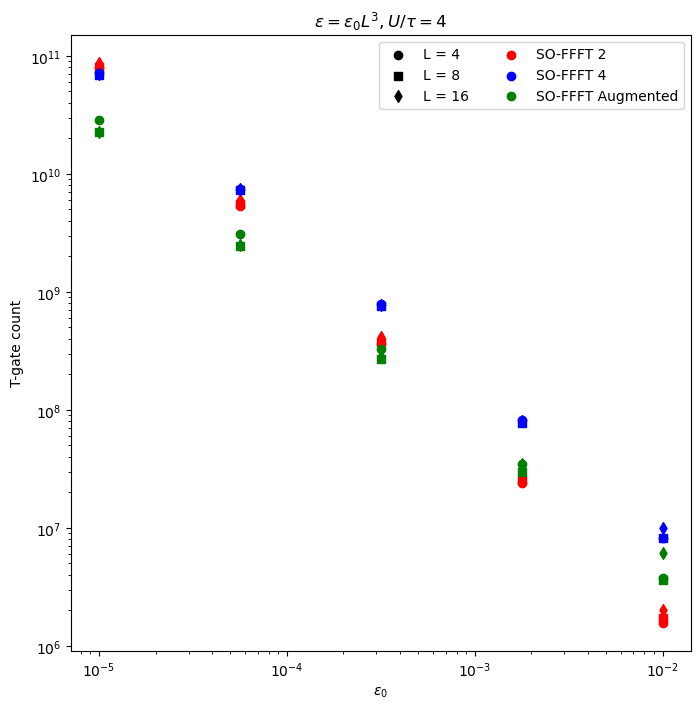

In [12]:
logeps_list = np.linspace(-5, -2, 5)
eps_list = np.pow(10, logeps_list)
Ls = [4, 8, 16]

colors = ['r', 'b', 'g']
marker_styles = ['o', 's', 'd']
comp_strats = ["SO-FFFT 2", "SO-FFFT 4", "SO-FFFT Augmented"]

fig, ax = plt.subplots(figsize = (8, 8))

for L, marker in zip(Ls, marker_styles):
    ax.scatter([],[], c = "k", marker = marker, label = f"L = {L}")
for strat, color in zip(comp_strats, colors):
    ax.scatter([],[], c = color, marker = "o", label = strat)

ax.set_xscale("log")
ax.set_yscale("log")
ax.legend(ncol = 2)
ax.set_xlabel(rf"$\varepsilon_0$")
ax.set_ylabel(f"T-gate count")
ax.legend(ncol = 2)
ax.set_title(rf"$\varepsilon = \varepsilon_0L^{D}, U / \tau = {U}$")

for gate_gen, color, comp_strat in zip(gate_gens_2, colors, comp_strats):
    print(comp_strat)
    for L, marker_style in zip(Ls, marker_styles):
        t_gates, u_gates = gate_gen(int(np.log2(L)), D)
        dcts = [adaptive_phase_estimation_resources(
            e * L**D, 
            t_gates, 
            unitary_gates=u_gates, 
            unitary_error_coefficients=get_error_coefficients(L, D, U, tau, comp_strat, False),
            x=x,
            synthesize_rotation_with="RUS"
        )
            for e in eps_list
               ]
        ys = [dict_to_t_count(d) for d in dcts]
        print(L)
        print(ys)
        ax.scatter(eps_list, ys, marker = marker_style, c = color)

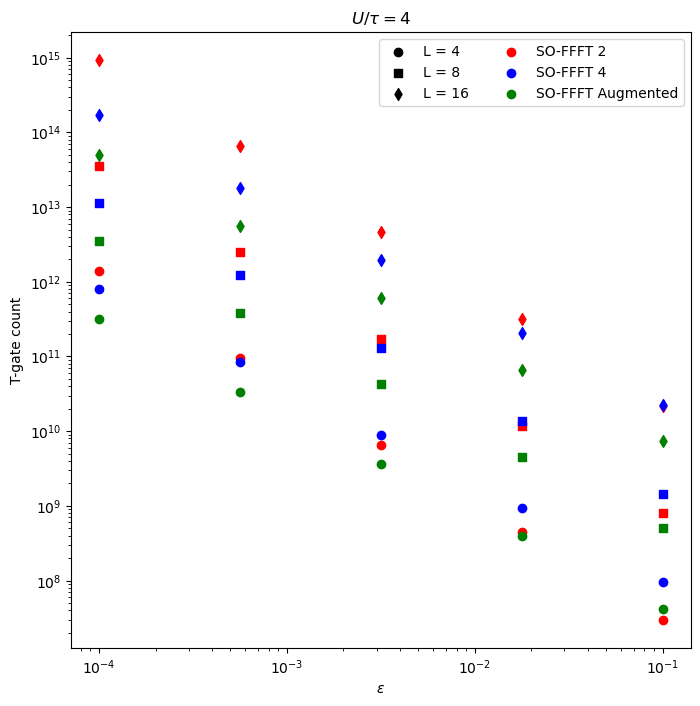

In [13]:
logeps_list = np.linspace(-4, -1, 5)
eps_list = np.pow(10, logeps_list)
Ls = [4, 8, 16]

colors = ['r', 'b', 'g']
marker_styles = ['o', 's', 'd']
comp_strats = ["SO-FFFT 2", "SO-FFFT 4", "SO-FFFT Augmented"]

fig, ax = plt.subplots(figsize = (8, 8))

for L, marker in zip(Ls, marker_styles):
    ax.scatter([],[], c = "k", marker = marker, label = f"L = {L}")
for strat, color in zip(comp_strats, colors):
    ax.scatter([],[], c = color, marker = "o", label = strat)

ax.set_xscale("log")
ax.set_yscale("log")
ax.legend(ncol = 2)
ax.set_xlabel(rf"$\varepsilon$")
ax.set_ylabel(f"T-gate count")
ax.legend(ncol = 2)
ax.set_title(rf"$U / \tau = {U}$")

for gate_gen, color, comp_strat in zip(gate_gens_2, colors, comp_strats):
    for L, marker_style in zip(Ls, marker_styles):
        t_gates, u_gates = gate_gen(int(np.log2(L)), D)
        dcts = [adaptive_phase_estimation_resources(
            e, 
            t_gates, 
            unitary_gates=u_gates, 
            unitary_error_coefficients=get_error_coefficients(L, D, U, tau, comp_strat, False),
            x=x,
            synthesize_rotation_with="RUS"
        )
            for e in eps_list
               ]
        ys = [dict_to_t_count(d) for d in dcts]
        ax.scatter(eps_list, ys, marker = marker_style, c = color)